In [27]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

In [28]:
image = cv2.imread('/content/image.jpg', cv2.IMREAD_GRAYSCALE)

Text(0.5, 1.0, 'Original Image')

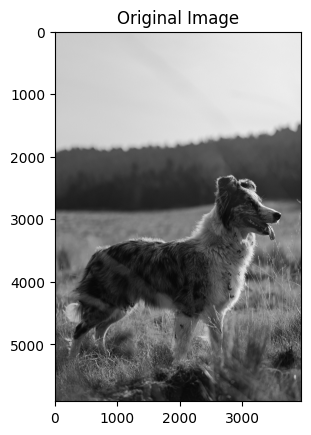

In [29]:
plt.imshow(image, cmap="gray")
plt.title("Original Image")

In [30]:
def add_salt_pepper_noise(image, probability = 0.3):
  noisy = image.copy()

  random = np.random.rand(*image.shape)

  noisy[random < probability / 2] = 0
  noisy[random > 1 - probability / 2] = 255

  return noisy

Text(0.5, 1.0, 'Noisy Image')

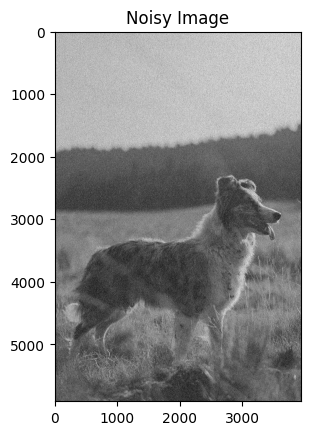

In [31]:
prob = 0.3

noisy = add_salt_pepper_noise(image, prob)

plt.imshow(noisy, cmap = "gray")
plt.title("Noisy Image")

In [32]:
def mirror_pad(image, pad):
  return np.pad(image, pad_width=pad, mode='reflect')

In [33]:
def mean_filter(image, kernel_size=3, stride=1):
  pad = kernel_size // 2
  padded = mirror_pad(image, pad).astype(np.float32)

  # shape: (H, W, kernel_size, kernel_size)
  windows = sliding_window_view(padded, (kernel_size, kernel_size))

  # apply stride by subsampling the window grid
  windows = windows[::stride, ::stride]

  result = windows.mean(axis=(-1, -2))
  return result.astype(np.uint8)

Text(0.5, 1.0, 'Mean Filter (kernel=3, stride=1)')

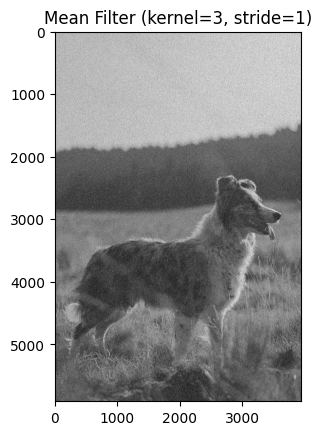

In [34]:
mean_filtered = mean_filter(noisy, kernel_size=3, stride=1)

plt.imshow(mean_filtered, cmap="gray")
plt.title("Mean Filter (kernel=3, stride=1)")

In [35]:
def median_filter(image, kernel_size=3, stride=1):
  pad = kernel_size // 2
  padded = mirror_pad(image, pad)

  windows = sliding_window_view(padded, (kernel_size, kernel_size))
  windows = windows[::stride, ::stride]

  result = np.median(windows, axis=(-1, -2))
  return result.astype(np.uint8)

Text(0.5, 1.0, 'Median Filter (kernel=3, stride=1)')

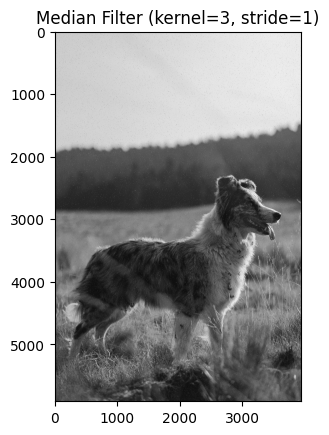

In [36]:
median_filtered = median_filter(noisy, kernel_size=3, stride=1)

plt.imshow(median_filtered, cmap="gray")
plt.title("Median Filter (kernel=3, stride=1)")

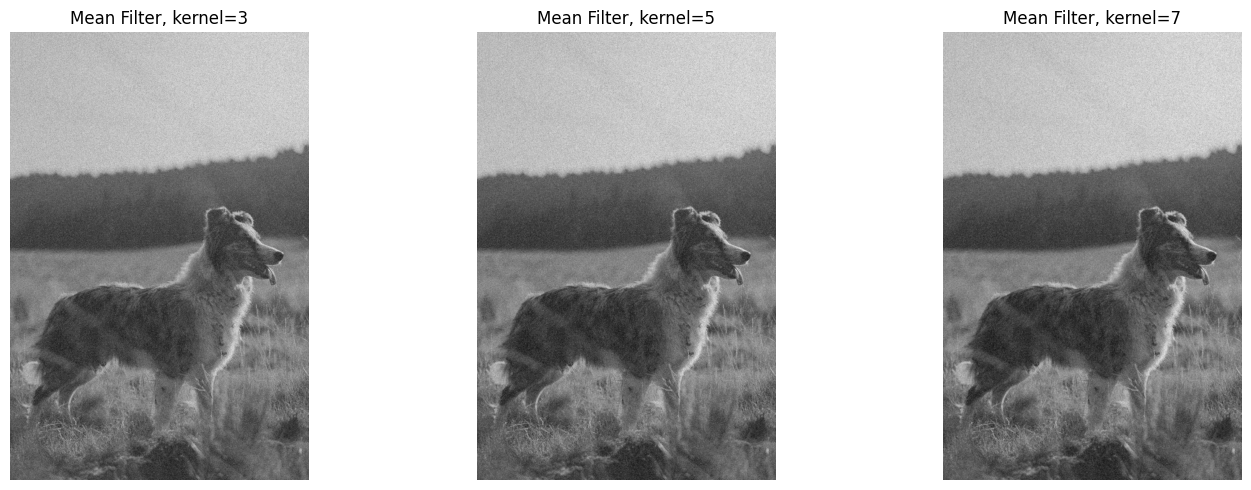

In [37]:
kernel_sizes = [3, 5, 7]

fig, axes = plt.subplots(1, len(kernel_sizes), figsize=(15, 5))

for ax, k in zip(axes, kernel_sizes):
  result = mean_filter(noisy, kernel_size=k, stride=1)
  ax.imshow(result, cmap="gray")
  ax.set_title(f"Mean Filter, kernel={k}")
  ax.axis("off")

plt.tight_layout()
plt.show()

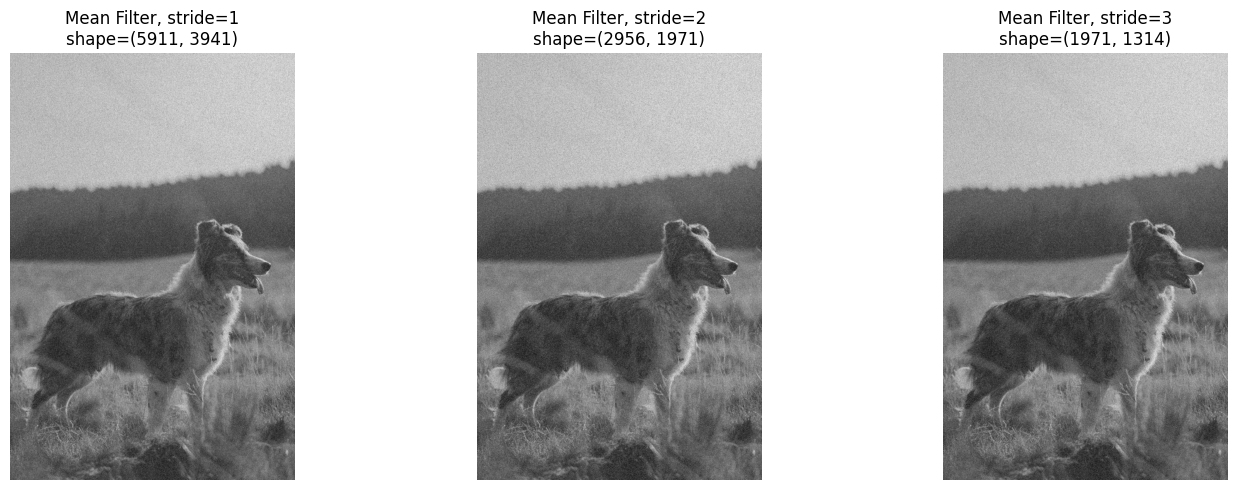

In [38]:
strides = [1, 2, 3]

fig, axes = plt.subplots(1, len(strides), figsize=(15, 5))

for ax, s in zip(axes, strides):
  result = mean_filter(noisy, kernel_size=3, stride=s)
  ax.imshow(result, cmap="gray")
  ax.set_title(f"Mean Filter, stride={s}\nshape={result.shape}")
  ax.axis("off")

plt.tight_layout()
plt.show()

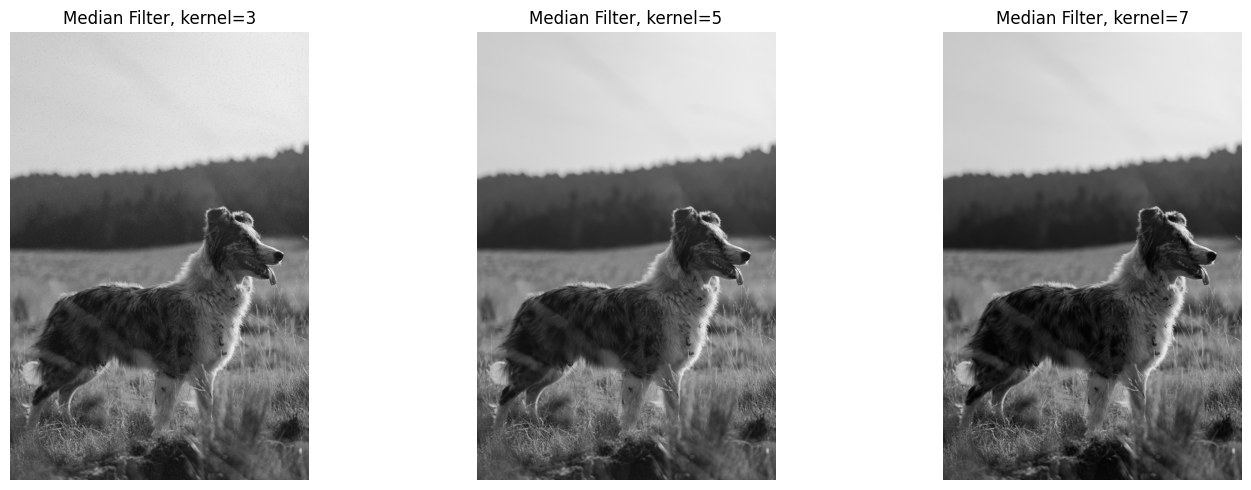

In [39]:
fig, axes = plt.subplots(1, len(kernel_sizes), figsize=(15, 5))

for ax, k in zip(axes, kernel_sizes):
  result = median_filter(noisy, kernel_size=k, stride=1)
  ax.imshow(result, cmap="gray")
  ax.set_title(f"Median Filter, kernel={k}")
  ax.axis("off")

plt.tight_layout()
plt.show()

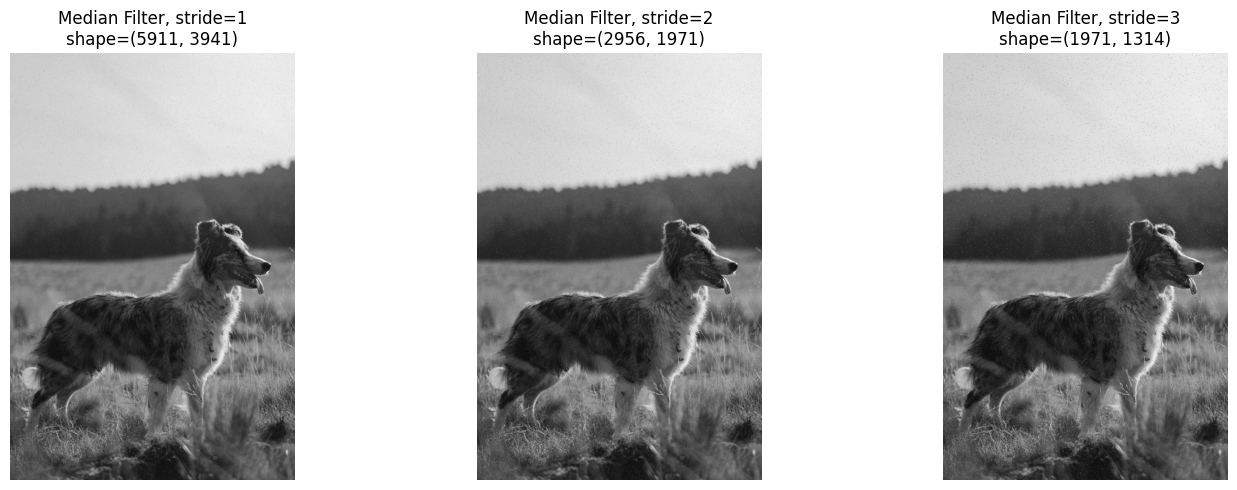

In [40]:
fig, axes = plt.subplots(1, len(strides), figsize=(15, 5))

for ax, s in zip(axes, strides):
  result = median_filter(noisy, kernel_size=3, stride=s)
  ax.imshow(result, cmap="gray")
  ax.set_title(f"Median Filter, stride={s}\nshape={result.shape}")
  ax.axis("off")

plt.tight_layout()
plt.show()

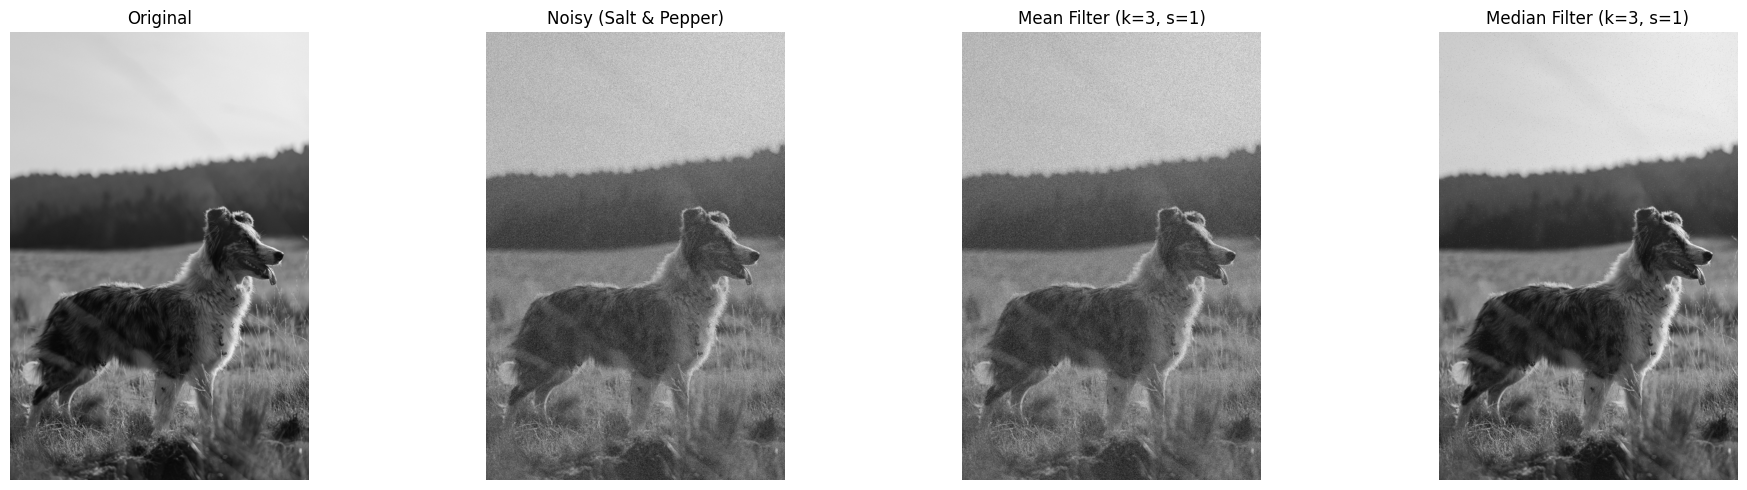

In [41]:
k, s = 3, 1

mean_result = mean_filter(noisy, kernel_size=k, stride=s)
median_result = median_filter(noisy, kernel_size=k, stride=s)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(noisy, cmap="gray")
axes[1].set_title("Noisy (Salt & Pepper)")
axes[1].axis("off")

axes[2].imshow(mean_result, cmap="gray")
axes[2].set_title(f"Mean Filter (k={k}, s={s})")
axes[2].axis("off")

axes[3].imshow(median_result, cmap="gray")
axes[3].set_title(f"Median Filter (k={k}, s={s})")
axes[3].axis("off")

plt.tight_layout()
plt.show()